# Electron and Proton DAQs with Viz

Let's get some viz going.
Some of this with help by ChatGPT

## Imports

In [9]:
# Import bluesky and ophyd
import bluesky.plan_stubs as bps  # noqa: F401
import bluesky.plans as bp  # noqa: F401
from bluesky.callbacks.best_effort import BestEffortCallback
from bluesky.run_engine import RunEngine, autoawait_in_bluesky_event_loop

from ophyd_async.core import init_devices
from ophyd_async.epics import demo, testing

import matplotlib.pyplot as plt

from pprint import pprint

from pva_ntndarray_source_v2 import PvaNtNdArraySource # local import

## Start RunEngine

In [2]:
# Create a run engine and make ipython use it for `await` commands
RE = RunEngine(call_returns_result=True)
autoawait_in_bluesky_event_loop()

# Add a callback for plotting
bec = BestEffortCallback()
RE.subscribe(bec)

0

## Create Electron and Proton Devices

In [5]:
with init_devices():
    electron_daq = PvaNtNdArraySource(
        pv="ELECTRON-DAQ:trace",
        name="electron_daq",
    )

    proton_daq = PvaNtNdArraySource(
        pv="PROTON-DAQ:trace",
        name="proton_daq",
    )

## read one atomic payload

In [8]:
electron_reading = await electron_daq.read()
proton_reading = await proton_daq.read()
pprint(electron_reading)
pprint(proton_reading)

OrderedDict([('electron_daq_trace',
              {'timestamp': 1781823158.9958363,
               'value': array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   2,   3,   7,   9,  10,  19,
        24,  30,  32,  35,  39,  37,  42,  47,  50,  50,  49,  57,  59,
        59,  66,  69,  69,  70,  75,  78,  76,  82,  84,  85,  86,  92,
        95,  97,  97, 100,  97, 102, 107, 111, 107, 113, 116, 112, 122,
       130, 135, 134, 135, 141, 144, 141, 146, 150], dtype=uint16)}),
             ('electron_daq_timeStamp',
              {'timestamp': 1781823158.9958363, 'value': 1781823158.9958363}),
             ('electron_daq_uniqueId',
              {'timestamp': 1781823158.9958363, 'value': 10814}),
             ('electron_daq_dataTimeStamp',
              {'timestamp': 1781823158.9958363, 'v

## quick trace check

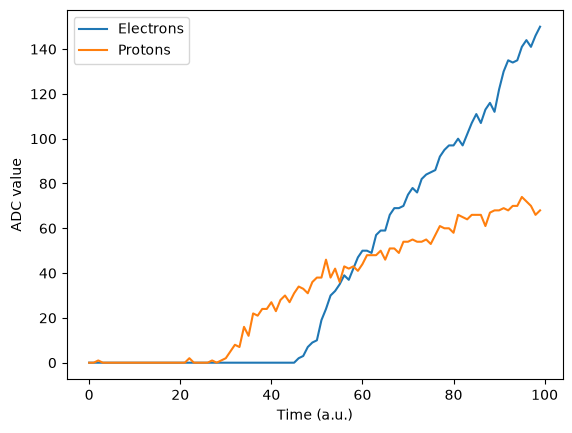

In [15]:
electron_yvals = electron_reading["electron_daq_trace"]["value"]
proton_yvals = proton_reading["proton_daq_trace"]["value"]

plt.plot(electron_yvals, label="Electrons")
plt.plot(proton_yvals, label="Protons")
plt.ylabel("ADC value")
plt.xlabel("Time (a.u.)")
plt.legend()

## run through Bluesky



Transient Scan ID: 1     Time: 2026-06-18 15:58:00
Persistent Unique Scan ID: 'da804816-ce44-40b7-9c7f-6b7394e16025'
New stream: 'primary'


C:\Users\scott\miniforge3\envs\epics\Lib\site-packages\bluesky\callbacks\best_effort.py:196: UserWarning: Omitting electron_daq_trace from plot because dtype is array
  warn(
C:\Users\scott\miniforge3\envs\epics\Lib\site-packages\bluesky\callbacks\core.py:348: UserWarning: The key electron_daq_trace will be skipped because LiveTable does not know how to display the dtype array
  warnings.warn(  # noqa: B028


+-----------+------------+------------------------+-----------------------+----------------------------+-----------------------+-----------------------------+-----------------------+-----------------+-----------------------+-------------------------+-------------------------+
|   seq_num |       time | electron_daq_timeStamp | electron_daq_uniqueId | electron_daq_dataTimeStamp | electron_daq_shot_num | electron_daq_start_shot_num | electron_daq_trace_nt | electron_daq_dt | electron_daq_trace_dt | electron_daq_trace_ymin | electron_daq_trace_ymax |
+-----------+------------+------------------------+-----------------------+----------------------------+-----------------------+-----------------------------+-----------------------+-----------------+-----------------------+-------------------------+-------------------------+
|         1 | 15:58:00.5 |         1781823479.998 |                 11777 |             1781823479.998 |                 11777 |                      706638 |           

RunEngineResult(run_start_uids=('da804816-ce44-40b7-9c7f-6b7394e16025',), plan_result='da804816-ce44-40b7-9c7f-6b7394e16025', exit_status='success', interrupted=False, reason='', exception=None)

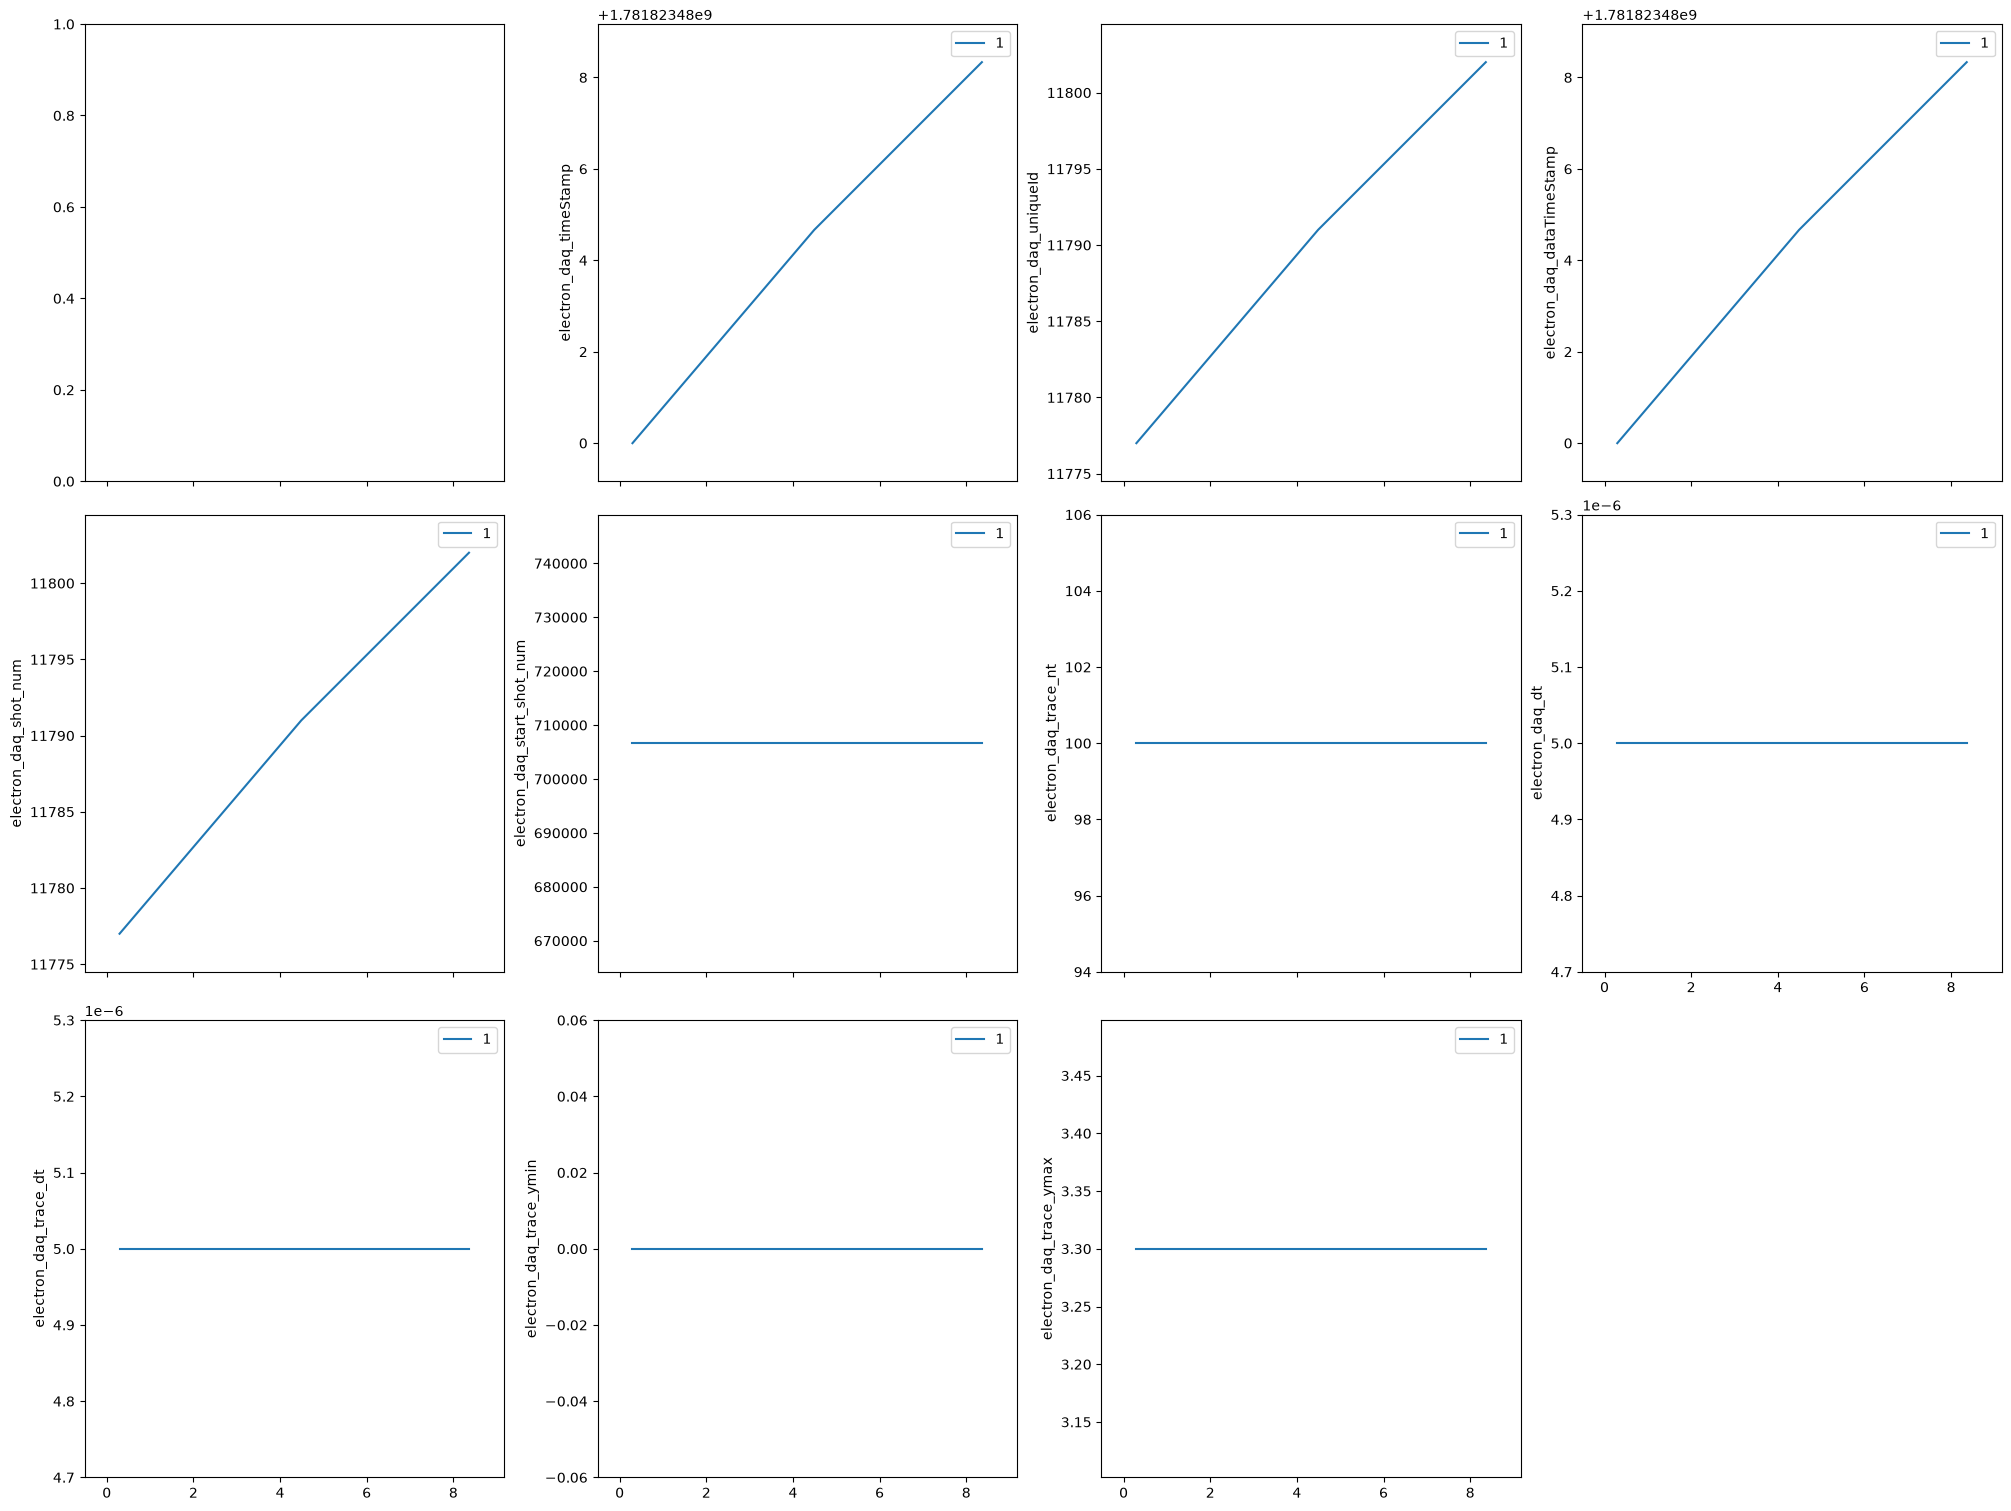

In [16]:
RE(bp.count([electron_daq], num=3))